In [1]:
# Google Colab / local setup
import os, sys, subprocess
from pathlib import Path
if "google.colab" in sys.modules:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
    CODE_ROOT = Path("/content/drive/MyDrive/msc project/code")
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q", "--no-deps", "-e",
        str(CODE_ROOT), 'catboost==1.2.10', 'rapidfuzz==3.14.3',
    ])
else:
    CODE_ROOT = next(
        path for path in (Path.cwd(), *Path.cwd().parents)
        if (path / "pyproject.toml").exists()
    )
os.chdir(CODE_ROOT)
sys.path.insert(0, str(CODE_ROOT))
CODE = CODE_ROOT

# 06i - Cross-index comparison

## Methodology

This cross-index synthesis compares original H1, side-calibrated, coverage-first, nine-model ensemble and channel policies with realised trades during July 2025-March 2026. The three ensemble rules are defined in 06g, and each feature set remains separate; correlated policies are evaluated independently rather than summed.

USA500 and USATECH are separate. Every economic table reports Net, Sharpe,
Sortino and drawdown after a fixed all-in round-trip deduction: 2 bps (0.02%)
for USA500 and 3 bps (0.03%) for USATECH. This covers bid-ask spread plus
commission/slippage; bar-specific spreads remain diagnostic, not additional
costs. Inputs stop before `2026-04-01 00:00 UTC`; Q2-2026 is evaluated separately in Notebook 07 and
no model is refitted here.

In [2]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from experiments.build_notebook_06 import MODEL_LABELS

STREAMS = ("usa500", "usatech")
BASE = CODE_ROOT / "experiments" / "cache"

def feature_label(value):
    if value == "selected_base":
        return "Price/VIX base"
    if value == "deberta_matched":
        return "DeBERTa matched"
    if value.endswith("_matched"):
        return "LLM matched"
    if value.endswith("_full"):
        return "LLM full"
    return value.replace("_", " ").title()

def ensemble_label(value):
    return {
        "soft_vote": "Equal probability average (soft vote)",
        "directional_majority": "Directional vote (5/9 majority)",
        "stack": "Causal logistic meta-model (stack)",
        "best_single": "Best single model",
    }[value]

def channel_metrics(ledger, start, end):
    start, end = pd.Timestamp(start), pd.Timestamp(end)
    work = ledger.copy(); work["entry_time"] = pd.to_datetime(work["entry_time"], utc=True)
    calendar = pd.date_range(start.normalize(), end.normalize(), freq="1D", inclusive="left", tz="UTC")
    daily = work.set_index("entry_time")["net_return"].resample("1D").sum().reindex(calendar, fill_value=0.0)
    mean, std = float(daily.mean()), float(daily.std(ddof=1))
    downside = daily[daily.lt(0)]; scale = float(np.sqrt(np.mean(np.square(downside)))) if len(downside) else 0.0
    equity = (1 + daily).cumprod(); drawdown = equity / equity.cummax() - 1
    return {"trades": len(work), "trades_per_day": len(work) / len(calendar),
            "n_long": int(work["side"].astype(str).str.lower().eq("long").sum()),
            "n_short": int(work["side"].astype(str).str.lower().eq("short").sum()),
            "net_return": float(work["net_return"].sum()),
            "daily_sharpe": mean / std * np.sqrt(365) if std > 0 else 0.0,
            "daily_sortino": mean / scale * np.sqrt(365) if scale > 0 else 0.0,
            "max_drawdown": float(drawdown.min()) if len(drawdown) else 0.0}

rows = []
for stream in STREAMS:
    original = pd.read_parquet(BASE / "index_replication" / stream / "forward_summary.parquet")
    original = original[original["trades"].gt(0)]
    for row in original.itertuples(index=False):
        rows.append({"Index": stream.upper(), "Experiment": "Original H1 quality-first", "Policy": f"{feature_label(row.arm)} / {MODEL_LABELS[row.model_name]}",
                     **{name: getattr(row, name) for name in ("trades", "trades_per_day", "n_long", "n_short", "net_return", "daily_sharpe", "daily_sortino", "max_drawdown")}})
    coverage_result = json.loads((BASE / "index_trade_coverage" / stream / "result.json").read_text(encoding="utf-8"))
    assert coverage_result["q2_loaded"] is False and coverage_result["evidence_role"] == "secondary_reused_forward"
    coverage = pd.read_parquet(BASE / "index_trade_coverage" / stream / "forward_summary.parquet")
    coverage = coverage[coverage["trades"].gt(0)]
    for row in coverage.itertuples(index=False):
        rows.append({"Index": stream.upper(), "Experiment": "Coverage-first", "Policy": f"{feature_label(row.arm)} / {MODEL_LABELS[row.model_name]}",
                     **{name: getattr(row, name) for name in ("trades", "trades_per_day", "n_long", "n_short", "net_return", "daily_sharpe", "daily_sortino", "max_drawdown")}})
    side_result = json.loads((BASE / "index_side_calibration" / stream / "result.json").read_text(encoding="utf-8"))
    assert side_result["q2_loaded"] is False and side_result["evidence_role"] == "secondary_reused_forward_posthoc_diagnostic"
    side = pd.read_parquet(BASE / "index_side_calibration" / stream / "forward_summary.parquet")
    side = side[side["trades"].gt(0)]
    for row in side.itertuples(index=False):
        rows.append({"Index": stream.upper(), "Experiment": "Side-calibrated", "Policy": f"{feature_label(row.arm)} / {MODEL_LABELS[row.model_name]}",
                     **{name: getattr(row, name) for name in ("trades", "trades_per_day", "n_long", "n_short", "net_return", "daily_sharpe", "daily_sortino", "max_drawdown")}})
    ensemble_result = json.loads((BASE / "index_all_model_ensemble" / stream / "result.json").read_text(encoding="utf-8"))
    assert ensemble_result["q2_loaded"] is False and ensemble_result["evidence_role"] == "secondary_reused_forward_diagnostic"
    ensemble = pd.read_parquet(BASE / "index_all_model_ensemble" / stream / "forward_summary.parquet")
    ensemble = ensemble[ensemble["trades"].gt(0)]
    for row in ensemble.itertuples(index=False):
        experiment = "Nine-model ensemble" if row.role == "ensemble" else "Best single-model control"
        model = "Nine base models" if row.model_name == "ALL_NINE" else MODEL_LABELS[row.model_name]
        rows.append({"Index": stream.upper(), "Experiment": experiment,
                     "Policy": f"{feature_label(row.arm)} / {ensemble_label(row.variant)} / {model}",
                     **{name: getattr(row, name) for name in ("trades", "trades_per_day", "n_long", "n_short", "net_return", "daily_sharpe", "daily_sortino", "max_drawdown")}})
    channel_root = BASE / "index_channel_replication" / stream
    channel_protocol = json.loads((channel_root / "protocol.json").read_text(encoding="utf-8"))
    channel = pd.read_parquet(channel_root / "ledgers" / "forward_rr2.parquet")
    rows.append({"Index": stream.upper(), "Experiment": "Channel RR2", "Policy": "window60 / RR2",
                 **channel_metrics(channel, *channel_protocol["stages"]["forward"])})
active = pd.DataFrame(rows)

## Cross-index economic results

Method: The synthesis compares realised July 2025-March 2026 policies separately by index, with each nine-model row applying one of the three frozen 06g combination rules to one feature set rather than pooling feature sets or correlated policies.

In [3]:
# economic-table
view = active.rename(columns={
    "trades": "Trades", "trades_per_day": "Trades/day", "n_long": "LONG", "n_short": "SHORT",
    "net_return": "Net %", "daily_sharpe": "Sharpe", "daily_sortino": "Sortino", "max_drawdown": "Max drawdown %",
})
view["Net %"] *= 100; view["Max drawdown %"] *= 100
view = view.sort_values(["Net %", "Sortino", "Sharpe"], ascending=False)
display(view[["Index", "Experiment", "Policy", "Trades", "Trades/day", "LONG", "SHORT", "Net %", "Sharpe", "Sortino", "Max drawdown %"]].round(3))
best = view.iloc[0]
print(f"Takeaway: {best['Index']} {best['Experiment']} has the highest Net at {best['Net %']:.2f}% with {best['Trades/day']:.3f} trades per day.")

,Index,Experiment,Policy,Trades,Trades/day,LONG,SHORT,Net %,Sharpe,Sortino,Max drawdown %
17,USA500,Nine-model ensemble,Price/VIX base / Directional vote (5/9 majorit...,273,0.996,177,96,2.137,0.753,0.427,-1.758
19,USA500,Nine-model ensemble,Price/VIX base / Causal logistic meta-model (s...,5,0.018,2,3,0.965,0.860,0.527,-0.309
2,USA500,Coverage-first,LLM matched / MLP,6,0.022,5,1,0.927,1.153,0.903,-0.072
42,USATECH,Nine-model ensemble,LLM full / Equal probability average (soft vot...,23,0.084,6,17,0.845,0.618,0.113,-1.481
31,USATECH,Side-calibrated,LLM full / Linear SVM,44,0.161,0,44,0.841,0.417,0.182,-1.584
24,USATECH,Original H1 quality-first,LLM full / XGBoost,24,0.088,8,16,0.752,1.238,0.378,-0.349
4,USA500,Side-calibrated,LLM full / LogReg,10,0.036,0,10,0.620,0.658,0.110,-0.393
36,USATECH,Side-calibrated,LLM matched / GRU,3,0.011,3,0,0.564,1.546,0.000,0.000
39,USATECH,Nine-model ensemble,DeBERTa matched / Equal probability average (s...,5,0.018,1,4,0.339,1.171,0.193,-0.123
25,USATECH,Original H1 quality-first,LLM full / LSTM,37,0.135,2,35,0.315,0.305,0.050,-0.675


Takeaway: USA500 Nine-model ensemble has the highest Net at 2.14% with 0.996 trades per day.


## One quantity-quality figure

Method: Each point is one active policy; horizontal position is trade frequency and vertical position is net return, with no portfolio aggregation.

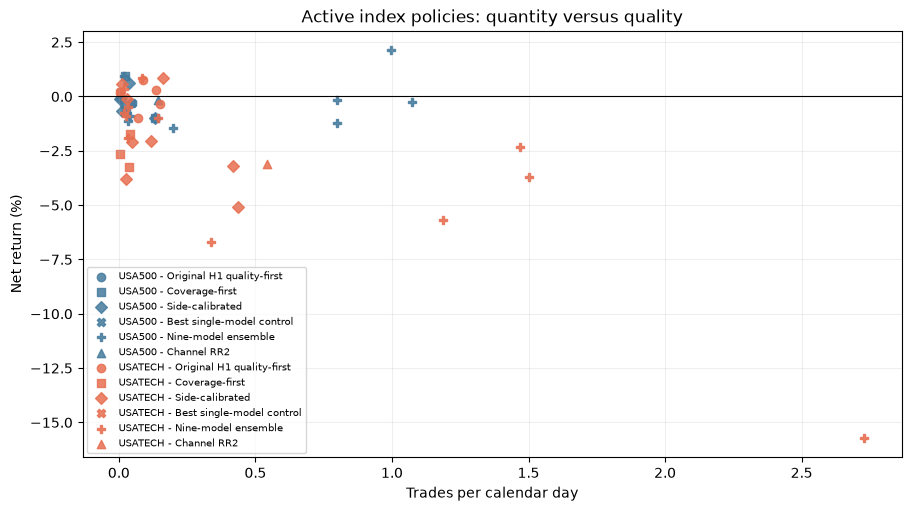

Takeaway: Higher trade count is useful only where the point does not sacrifice the accompanying economic quality.


In [4]:
# economic-figure
colors = {"USA500": "#457b9d", "USATECH": "#e76f51"}
markers = {"Original H1 quality-first": "o", "Coverage-first": "s", "Side-calibrated": "D",
           "Nine-model ensemble": "P", "Best single-model control": "X", "Channel RR2": "^"}
fig, ax = plt.subplots(figsize=(9, 5), layout="constrained")
for (index, experiment), scope in active.groupby(["Index", "Experiment"], sort=False):
    ax.scatter(scope["trades_per_day"], 100 * scope["net_return"], label=f"{index} - {experiment}",
               color=colors[index], marker=markers[experiment], alpha=.85)
ax.axhline(0, color="black", lw=.8); ax.set_xlabel("Trades per calendar day"); ax.set_ylabel("Net return (%)")
ax.set_title("Active index policies: quantity versus quality"); ax.grid(alpha=.2); ax.legend(fontsize=7)
plt.show()
print("Takeaway: Higher trade count is useful only where the point does not sacrifice the accompanying economic quality.")

Paired inference: A HAC/Holm sentiment comparison is not estimable because no base/sentiment pair for the same model passed the H1 gate on both sides.